# AC Countertrend

1. **Bull market:** 40-day EMA > 80-day EMA
2. **Pullback:** `(20-day high close - close) / 40-day std of daily returns`
3. **Entry:** Bull market and pullback at least `min_pullback` standard deviations (all-in)
4. **Exit:** Close above `exit_ma`-day SMA, 15% stop loss, or after 200 trading days. Bear exit disabled (`exit_on_bear=False`) for testing.

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

import pinkfish as pf
import strategy

pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [2]:
plt.rcParams['figure.figsize'] = (10, 7)

Global data

In [3]:
symbol = 'SPY'
capital = 10000
start = datetime.datetime(*pf.SP500_BEGIN)
end = datetime.datetime.now()

Run strategy

In [4]:
options = {
    'use_adj': True,
    'use_cache': True,
    'margin': 1,
    'std_period': 40,
    'high_period': 10,
    'ema_fast': 40,
    'ema_slow': 80,
    'hold_period': 200,
    'min_pullback': 3.0,
    'exit_ma': 20,
    'stop_loss_pct': 0.15,
    'exit_on_bear': False,
}

s = strategy.Strategy(symbol, capital, start, end, options)
s.run()

View logs

In [5]:
s.tlog.tail()

,entry_date,entry_price,exit_date,exit_price,pl_points,pl_cash,qty,cumul_total,direction,symbol
1709,2026-05-27,748.53,2026-05-28,752.66,4.13,755.67,183,128470.82,LONG,SPY
1710,2026-06-03,752.30,2026-06-04,755.14,2.84,523.06,184,128993.88,LONG,SPY
1711,2026-06-05,735.65,2026-06-15,752.89,17.24,3240.29,188,132234.17,LONG,SPY
1712,2026-06-16,748.40,2026-06-18,746.74,-1.66,-315.78,190,131918.40,LONG,SPY
1713,2026-06-22,744.39,2026-06-26,734.94,-9.45,-1795.89,190,130122.51,LONG,SPY


In [6]:
s.dbal.tail()

,high,low,close,shares,cash,leverage,state
date,,,,,,,
2026-06-22,141918.40,141918.40,141918.40,190,484.29,1.00,O
2026-06-23,139864.50,139864.50,139864.50,190,484.29,1.00,-
2026-06-24,139799.89,139799.89,139799.89,190,484.29,1.00,-
2026-06-25,140001.29,140001.29,140001.29,190,484.29,1.00,-
2026-06-26,140122.51,140122.51,140122.51,0,140122.51,1.00,X


Strategy statistics

In [7]:
pf.print_full(s.stats)

start                                                  1993-05-24
end                                                    2026-06-26
beginning_balance                                           10000
ending_balance                                          140122.51
total_net_profit                                        130122.51
gross_profit                                            376206.69
gross_loss                                             -246084.18
profit_factor                                                1.53
return_on_initial_capital                                 1301.23
annual_return_rate                                           8.30
trading_period                           33 years 1 months 2 days
pct_time_in_market                                          44.72
margin                                                          1
avg_leverage                                                 1.00
max_leverage                                                 1.00
min_levera

Benchmark

In [8]:
benchmark = pf.Benchmark(symbol, capital, s.start, s.end, use_adj=True)
benchmark.run()

Equity curves

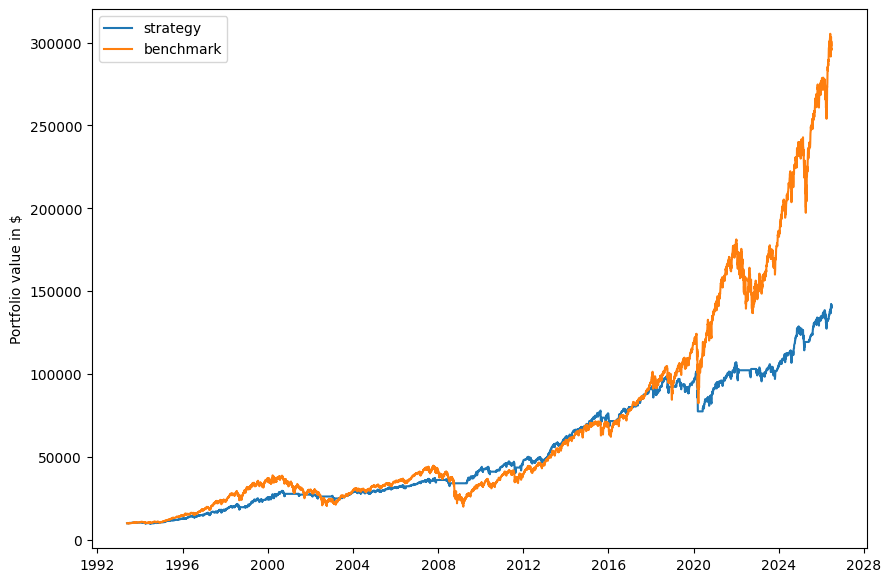

In [9]:
pf.plot_equity_curve(s.dbal, benchmark=benchmark.dbal)

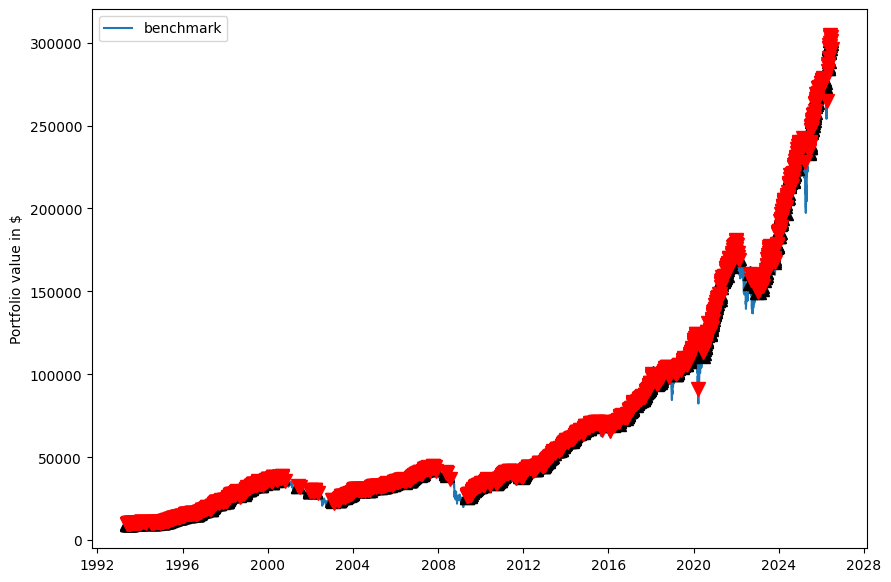

In [10]:
pf.plot_trades(s.dbal, benchmark=benchmark.dbal)

Bar graph: strategy vs benchmark

,strategy,benchmark
annual_return_rate,8.30,10.78
max_closed_out_drawdown,-23.81,-55.17
annualized_return_over_max_drawdown,0.35,0.20
best_month,12.70,23.60
worst_month,-23.81,-30.98
sharpe_ratio,0.75,0.64
sortino_ratio,0.65,0.82
monthly_std,2.65,4.45
annual_std,9.19,16.83


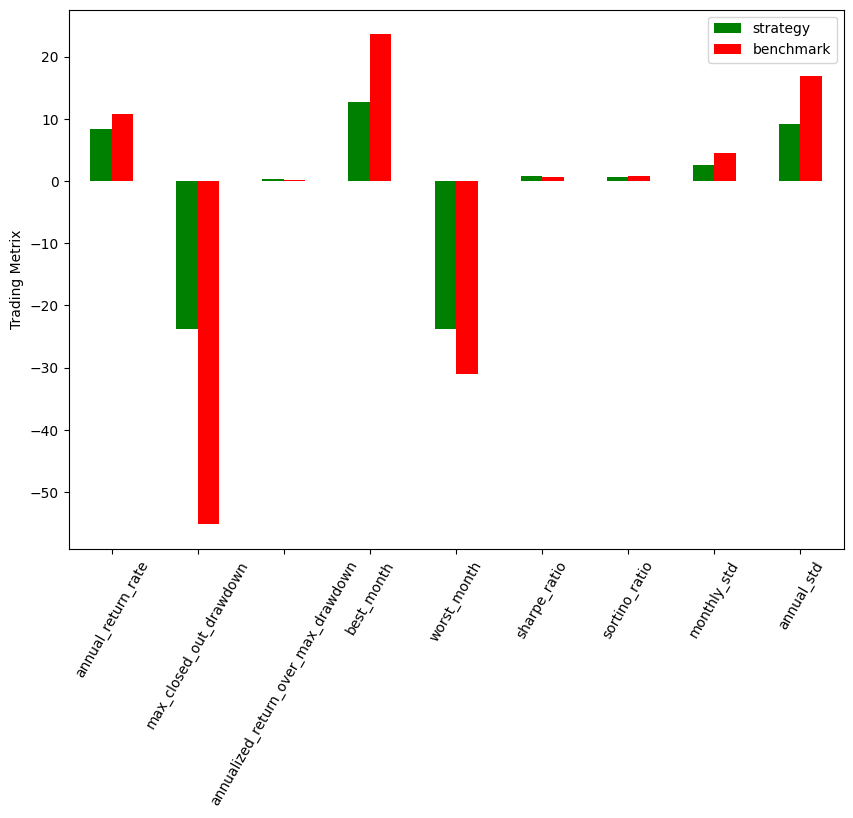

In [11]:
pf.plot_bar_graph(s.stats, benchmark.stats)

Prettier graphs

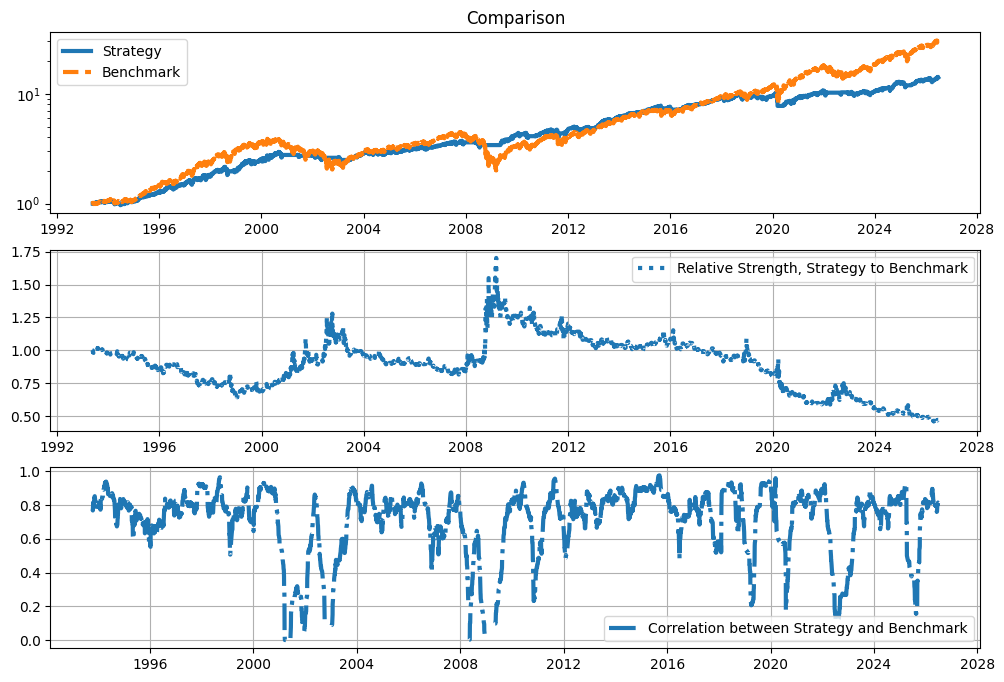

In [12]:
returns = s.dbal['close']
benchmark_returns = benchmark.dbal['close']
pf.prettier_graphs(returns, benchmark_returns,
                   dbal_label='Strategy', benchmark_label='Benchmark')